Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Moons Classification Assessment**

---

### **Import Libraries**

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from sklearn.datasets import make_moons
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


2026-06-11 16:08:38.751699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-11 16:08:38.807058: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-11 16:08:38.825370: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-11 16:08:38.890856: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [2]:
n_samples = 1000

X, y = make_moons(n_samples,
                  noise=0.03,
                  random_state=42)

In [3]:
moons = pd.DataFrame({"X0": X[:, 0], 
                      "X1": X[:, 1], 
                      "label":y})

moons.head()

,X0,X1,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


In [4]:
moons.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

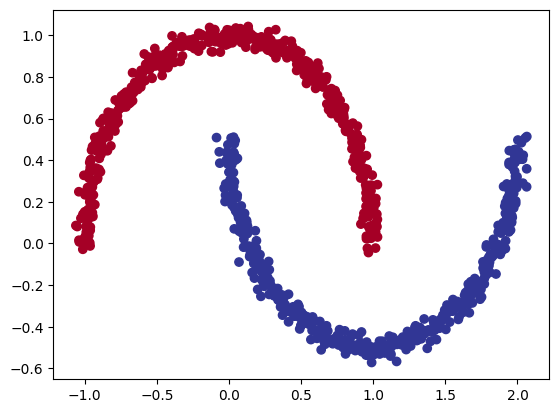

In [5]:
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [6]:
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

### **Create Model**

In [7]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=50,
                    validation_split=0.2)

I0000 00:00:1781194626.617771   16465 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781194627.261448   16465 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781194627.261522   16465 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781194627.266294   16465 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781194627.266373   16465 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

11/20 [===============>..............] - ETA: 0s - loss: 0.6839 - accuracy: 0.6392 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


20/20 [==============================] - 3s 16ms/step - loss: 0.6591 - accuracy: 0.7266 - val_loss: 0.5777 - val_accuracy: 0.9375
Epoch 2/50
20/20 [==============================] - 0s 7ms/step - loss: 0.5738 - accuracy: 0.8172 - val_loss: 0.4834 - val_accuracy: 0.9500
Epoch 3/50
20/20 [==============================] - 0s 8ms/step - loss: 0.5103 - accuracy: 0.8188 - val_loss: 0.4001 - val_accuracy: 0.9500
Epoch 4/50
20/20 [==============================] - 0s 7ms/step - loss: 0.4477 - accuracy: 0.8313 - val_loss: 0.3253 - val_accuracy: 0.9375
Epoch 5/50
20/20 [==============================] - 0s 8ms/step - loss: 0.3877 - accuracy: 0.8484 - val_loss: 0.2615 - val_accuracy: 0.9375
Epoch 6/50
20/20 [==============================] - 0s 7ms/step - loss: 0.3433 - accuracy: 0.8578 - val_loss: 0.2150 - val_accuracy: 0.9375
Epoch 7/50
20/20 [==============================] - 0s 8ms/step - loss: 0.3144 - accuracy: 0.8609 - val_loss: 0.1900 - val_accuracy: 0.9500
Epoch 8/50
20/20 [============

### **Display Results**

In [10]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    x_input = np.c_[xx.ravel(), yy.ravel()]
    
    y_pred = model.predict(x_input)
    
    if model.output_shape[-1] > 1: 
        print("doing multiclass classification...")
        
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print('doing binary classification...')
        y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)
        
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

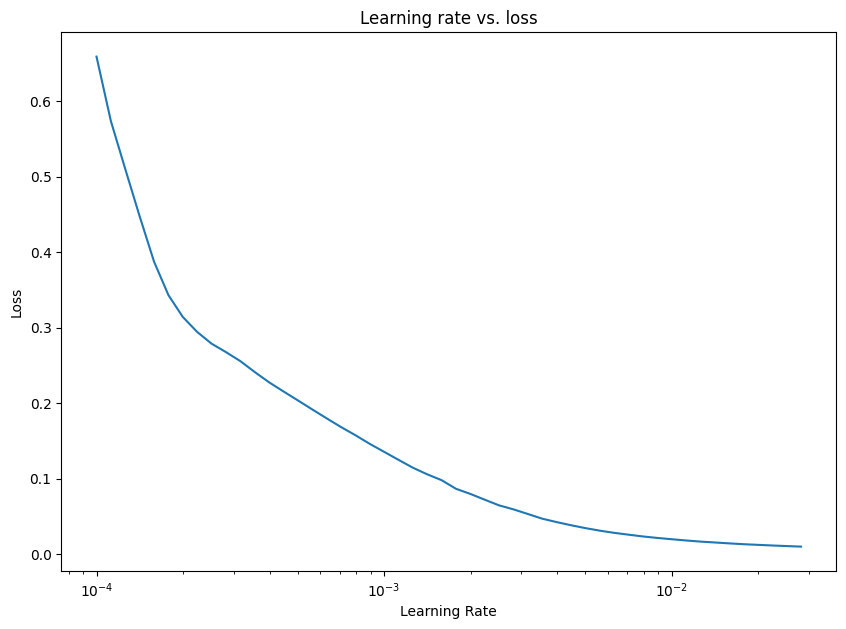

In [9]:
lrs = 1e-4 * (10 ** (np.arange(50)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

Text(0, 0.5, 'Loss')

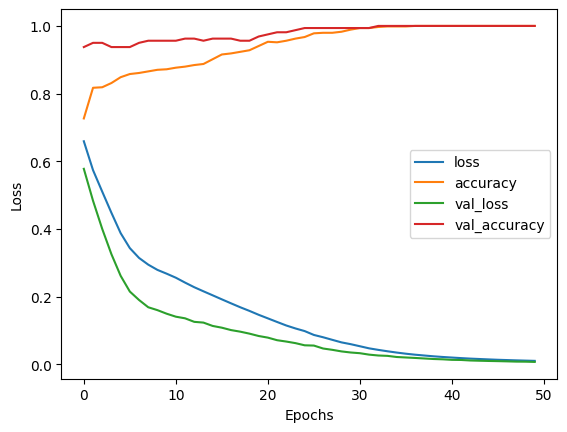

In [11]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')

313/313 [==============================] - 1s 2ms/step
doing binary classification...
313/313 [==============================] - 1s 2ms/step
doing binary classification...


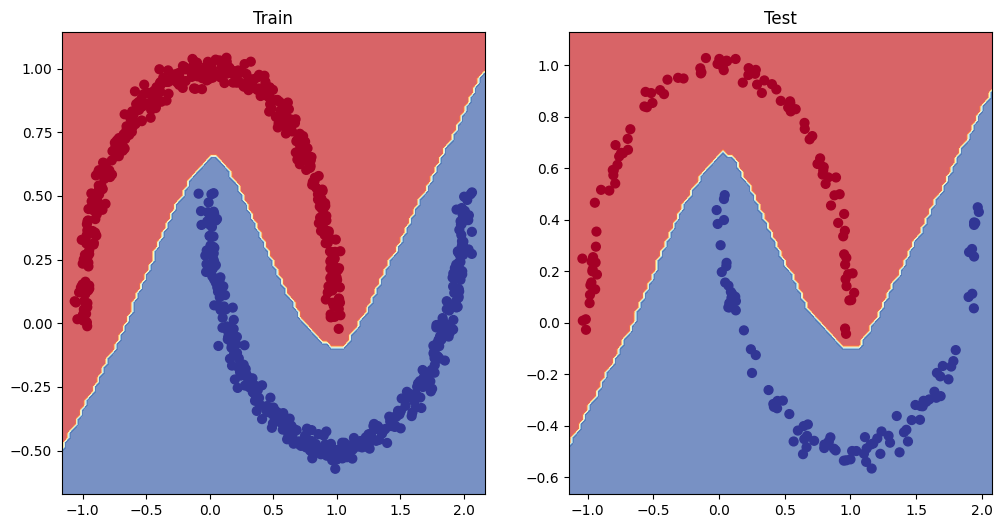

In [12]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model, X_test, y_test)

In [13]:
y_preds = model.predict(X_test)

confusion_matrix(y_test, tf.round(y_preds))

7/7 [==============================] - 0s 3ms/step


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


array([[101,   0],
       [  0,  99]])

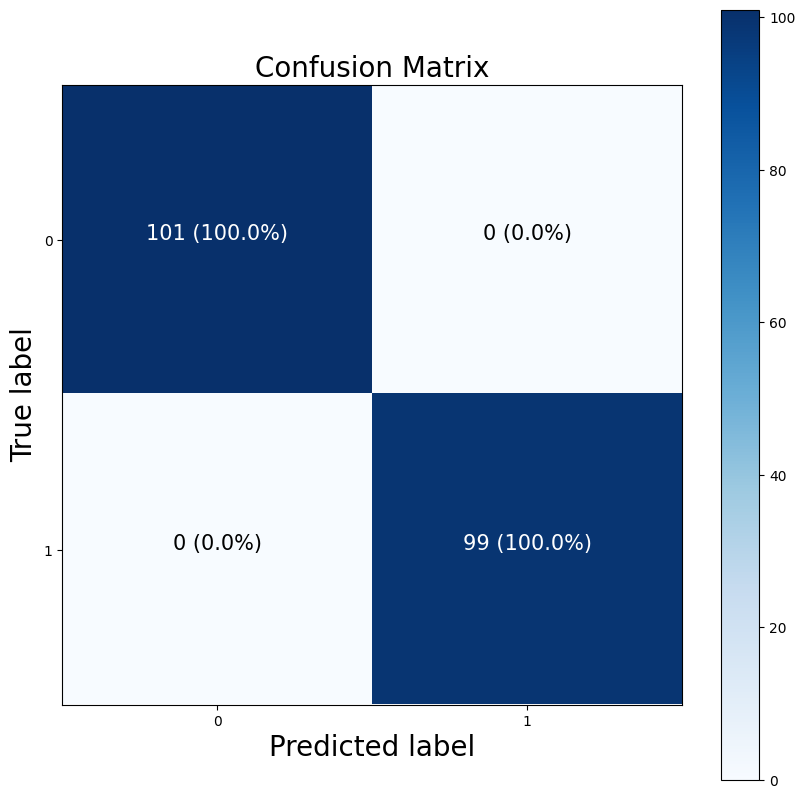

In [14]:
figsize = (10, 10)

# Create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
n_classes = cm.shape[0]

# Let's prettify it
fig, ax = plt.subplots(figsize=figsize)
# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues) # https://matplotlib.org/3.2.0/api/_as_gen/matplotlib.axes.Axes.matshow.html
fig.colorbar(cax)

classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

ax.set(title="Confusion Matrix",
       xlabel="Predicted label",
       ylabel="True label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.title.set_size(20)

threshold = (cm.max() + cm.min()) / 2.

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size=15)